# Imputation Comparison under a Latent-Factor Model

This notebook compares ways of handling zeros in a correlation analysis of metabolomic
abundances. Log-abundances are simulated from a latent-factor model, made relative by sample-
and feature-specific biases, and left-censored to create zeros. Every method is passed through
the same downstream pipeline, so the comparison isolates the treatment of the zeros.

The stages are:

1. imports, run settings, and output locations,
2. the simulation functions, the correlation pipeline, and the scoring rules,
3. the simulation design, run or loaded from disk,
4. the summary table of edge recovery,
5. `FigureS3.pdf`, and
6. the key numbers table.

Timing is recorded for the main computational steps and summarized at the end.

## 1. Imports and run settings

`RUN_SIMULATION = True` runs the full design and writes the tidy CSV. Setting it to `False`
loads the CSV written by an earlier run and rebuilds the summary table and Figure S3. `SMOKE = True`
runs a reduced configuration and writes to separate files, so the full-scale results are never
overwritten.

In [3]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests


%matplotlib inline

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Run settings.
RUN_SIMULATION = False
SMOKE = False

# Data-generating process.
N_SAMPLES = 100
N_FEATURES = 200
N_MODULES = 5
BLOCK_SIZE = 20
LOADING_RANGE = (1.0, 2.0)
MEAN_RANGE = (10.0, 14.0)
NOISE_SD = 1.0
N_MONTE_CARLO = 200_000

# Design.
CENSOR_MECHANISMS = ('feature', 'floor')
ZERO_PROPORTIONS = (0.3,) if SMOKE else (0.1, 0.2, 0.3, 0.5)
N_REPLICATES = 2 if SMOKE else 50

# Model fitting and sparsification.
MAX_EPOCHS = 50 if SMOKE else 1000
NUM_SIM = 5 if SMOKE else 100
LEARNING_RATE = 1e-2
BATCH_SIZE = 100
CORR_THRESHOLD = 0.2
BH_ALPHA = 0.05
SEC_RHO = 1.5

SUFFIX = '_smoke' if SMOKE else ''
RESULTS_PATH = f'../results/intermediate_results/sim_imputation_comparison{SUFFIX}.csv'
KEY_NUMBERS_PATH = (
    f'../results/intermediate_results/sim_imputation_comparison_key_numbers{SUFFIX}.csv'
)
FIG_DIR = '../results/figures/smoke' if SMOKE else '../results/figures'

os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

step_times = {}

def print_step_time(step_name, start_time):
    elapsed = time.perf_counter() - start_time
    step_times[step_name] = elapsed
    print(f"{step_name} finished in {elapsed:.2f} seconds")

print('RUN_SIMULATION:', RUN_SIMULATION)
print('SMOKE:', SMOKE)
print('Replicates:', N_REPLICATES)
print('Zero proportions:', ZERO_PROPORTIONS)
print('Tidy results:', RESULTS_PATH)
print('Figures:', FIG_DIR)

RUN_SIMULATION: False
SMOKE: False
Replicates: 50
Zero proportions: (0.1, 0.2, 0.3, 0.5)
Tidy results: ../results/intermediate_results/sim_imputation_comparison.csv
Figures: ../results/figures


## 2. Simulation functions

The first cell generates one replicate and its population correlation matrix, the second
applies the observation process, the third holds the correlation pipeline and the two
sparsifiers, and the fourth scores one estimate and runs one replicate over all methods.

In [5]:
def generate(rng, n, d, k, block, beta_range=LOADING_RANGE, mu_range=MEAN_RANGE, sigma=NOISE_SD):
    """Log-abundance matrix, module membership, and loadings for one replicate.

    The first k blocks of block features each load on one standard Gaussian factor with a
    loading drawn uniformly from beta_range and a random sign. Feature means are drawn
    uniformly from mu_range and the residual noise has standard deviation sigma. Features
    outside the blocks have module membership -1 and zero loading.
    """
    mu = rng.uniform(*mu_range, size=d)
    beta = np.zeros(d)
    module = -np.ones(d, dtype=int)
    for m in range(k):
        idx = np.arange(m * block, (m + 1) * block)
        module[idx] = m
        beta[idx] = rng.uniform(*beta_range, size=block) * rng.choice([-1, 1], size=block)
    f = rng.standard_normal((n, k))
    log_a = mu + sigma * rng.standard_normal((n, d))
    for j in range(d):
        if module[j] >= 0:
            log_a[:, j] += beta[j] * f[:, module[j]]
    return log_a, module, beta


def true_correlation(rng, d, k, beta, module, n_mc=N_MONTE_CARLO):
    """Population correlation matrix of the log-abundances, by Monte Carlo."""
    f = rng.standard_normal((n_mc, k))
    x = rng.standard_normal((n_mc, d))
    for j in range(d):
        if module[j] >= 0:
            x[:, j] += beta[j] * f[:, module[j]]
    return np.corrcoef(x, rowvar=False)


def restrict_to_modules(truth, module):
    """Set every correlation between features of different modules to zero.

    Only pairs within a module are correlated in the population, so the Monte Carlo
    estimates of the remaining entries are replaced by their population value of zero. The
    diagonal is set to one.
    """
    same_module = (module[:, None] == module[None, :]) & (module[:, None] >= 0)
    out = np.where(same_module, truth, 0.0)
    np.fill_diagonal(out, 1.0)
    return out

In [6]:
def observe(rng, log_a, zero_prop, censor='feature'):
    """Relative abundances with sample and feature biases, left-censored to create zeros.

    Each sample is multiplied by a bias drawn uniformly from (1e-3, 1e-1) and each feature by
    a bias drawn uniformly from (0.1, 1.0). With censor 'feature' the detection limit is the
    zero_prop quantile within each feature, so every feature carries the same proportion of
    zeros. With censor 'floor' the detection limit is the zero_prop quantile of all entries,
    so low-signal samples and low-abundance features carry more zeros.
    """
    n, d = log_a.shape
    log_obs = (log_a
               + np.log(rng.uniform(1e-3, 1e-1, size=(n, 1)))
               + np.log(rng.uniform(0.1, 1.0, size=(1, d))))
    y = np.exp(log_obs)
    if zero_prop > 0:
        th = np.quantile(y, zero_prop, axis=0) if censor == 'feature' else np.quantile(y, zero_prop)
        y = np.where(y < th, 0.0, y)
    return y

In [7]:
def corr_dense(data_log, threshold=CORR_THRESHOLD):
    """Correlation from a completed log matrix with the MetVAE routine.

    Entries equal to NaN are treated as missing and excluded pairwise. Absolute correlations
    below threshold are stored as exact zeros.
    """
    import torch
    from metvae.compute_corr import _compute_correlation

    with torch.no_grad():
        t = torch.as_tensor(data_log, dtype=torch.float64)
        return _compute_correlation(torch.exp(t), threshold=threshold).to_dense().numpy()


def fisher_edges(r, n, alpha=BH_ALPHA):
    """Edges whose correlations reject zero after Benjamini-Hochberg adjustment.

    The test is the two-sided Fisher z test at level alpha, applied to the strict upper
    triangle. Returns the selection indicator and the upper triangle index.
    """
    d = r.shape[0]
    iu = np.triu_indices(d, k=1)
    z = np.arctanh(np.clip(r[iu], -0.999999, 0.999999)) * np.sqrt(max(n - 3, 1))
    p = 2 * stats.norm.sf(np.abs(z))
    keep = multipletests(p, alpha=alpha, method='fdr_bh')[0]
    return keep, iu


def sec_edges(r, n, rho=SEC_RHO):
    """Edges retained by the SEC estimator at penalty rho.

    An edge is retained when its off-diagonal entry in the sparse estimate is nonzero.
    Returns the selection indicator and the upper triangle index.
    """
    import torch
    from metvae.sparse import _SEC

    with torch.no_grad():
        out = _SEC(torch.as_tensor(r, dtype=torch.float64), rho, n_samples=n).to_dense().numpy()
    iu = np.triu_indices(r.shape[0], k=1)
    return out[iu] != 0, iu

In [8]:
def score(est, truth, n, alpha=BH_ALPHA, rho=SEC_RHO):
    """Edge recovery under both sparsifiers for the reported comparison.

    The true edges are the pairs whose population correlation is nonzero. For each sparsifier
    the true positive rate, the false discovery proportion, and the number of selected edges
    are reported. False discovery rate is estimated by averaging false discovery
    proportions across replicates.
    """
    iu = np.triu_indices(truth.shape[0], k=1)
    true_edges = np.abs(truth[iu]) > 1e-8
    out = {}
    for tag, (keep, _) in (('bh', fisher_edges(est, n, alpha)), ('sec', sec_edges(est, n, rho))):
        tp = int((keep & true_edges).sum())
        fp = int((keep & ~true_edges).sum())
        out[f'tpr_{tag}'] = tp / true_edges.sum()
        out[f'fdr_{tag}'] = fp / max(keep.sum(), 1)
        out[f'n_edges_{tag}'] = int(keep.sum())
    return out


In [9]:
def run_replicate(rep, zero_prop, censor):
    """Score every imputation method on one replicate of the design.

    One data set is generated, censored at zero_prop under the given mechanism, and passed to
    each method. The oracle uses the complete log-abundances, the observed-only estimate
    treats zeros as missing, half-minimum replaces each zero by half the smallest observed
    value of its feature, the censored-normal estimate averages the MetVAE initialization draw
    over NUM_SIM draws, and the MetVAE estimates are obtained by training the model. Returns
    one record per method.
    """
    import torch
    from metvae.model import MetVAE, _random_initial
    torch.set_num_threads(3)

    rng = np.random.default_rng(10_000 * rep + int(100 * zero_prop))
    n, d, k, block = N_SAMPLES, N_FEATURES, N_MODULES, BLOCK_SIZE
    log_a, module, beta = generate(rng, n, d, k, block)
    truth = true_correlation(np.random.default_rng(rep), d, k, beta, module)
    truth = restrict_to_modules(truth, module)

    y = observe(rng, log_a, zero_prop, censor)
    df = pd.DataFrame(y, index=[f's{i}' for i in range(n)], columns=[f'f{j}' for j in range(d)])
    out = {}

    out['oracle'] = corr_dense(log_a)
    with np.errstate(divide='ignore'):
        out['observed_only'] = corr_dense(np.where(y > 0, np.log(y), np.nan))

    configs = [('metvae_linear', None, None), ('metvae_linear_L10', None, 10)]

    for label, hidden, latent in configs:
        model = MetVAE(data=df, meta=None, hidden_dims=hidden, latent_dim=latent,
                       use_gpu=False, seed=rep, feature_zero_threshold=1.0)
        if label == 'metvae_linear':
            # The censored-normal draw is the MetVAE initialization, used without refinement.
            acc = None
            for draw_seed in range(NUM_SIM):
                generator = torch.Generator().manual_seed(draw_seed)
                draw = _random_initial(y=model.clr_data, sample_size=n, num_zero=model.num_zero,
                                       mean=model.clr_mean, sd=model.clr_sd, generator=generator)
                r = corr_dense((draw + model.shift).numpy())
                acc = r if acc is None else acc + r
            out['censored_normal'] = acc / NUM_SIM
            with np.errstate(divide='ignore'):
                log_obs = np.where(y > 0, np.log(y), np.nan)
            half_min = np.log(0.5) + np.nanmin(log_obs, axis=0)
            out['half_minimum'] = corr_dense(np.where(np.isnan(log_obs), half_min, log_obs))
        fit_start = time.perf_counter()
        model.train(batch_size=BATCH_SIZE, num_workers=0, max_epochs=MAX_EPOCHS,
                    learning_rate=LEARNING_RATE)
        model.get_corr(num_sim=NUM_SIM, workers=1, threshold=CORR_THRESHOLD, seed=0)
        out[label] = model.corr_outputs['estimate'].to_dense().numpy()
        out[label + '_seconds'] = time.perf_counter() - fit_start
        del model

    method_order = (['oracle', 'observed_only', 'half_minimum', 'censored_normal']
                    + [c[0] for c in configs])
    rows = []
    for method in method_order:
        row = {'censor': censor, 'zero_prop': zero_prop, 'rep': rep, 'method': method}
        row.update(score(out[method], truth, n))
        row['fit_seconds'] = out.get(method + '_seconds', np.nan)
        rows.append(row)
    return rows


METHOD_ORDER = ['oracle', 'observed_only', 'half_minimum', 'censored_normal',
                'metvae_linear', 'metvae_linear_L10']
METHOD_LABELS = dict(zip(METHOD_ORDER, ['Oracle', 'Observed only', 'Half minimum',
    'Censored normal', 'MetVAE default', 'MetVAE latent 10']))
CENSOR_LABELS = {'feature': 'Feature-specific detection limit', 'floor': 'Common detection limit'}


## 3. Run or load the simulation

The design crosses the two censoring mechanisms with the zero proportions and the replicates.
Each replicate writes one record per method, and the accumulated table is written to disk after
every replicate.

In [11]:
step_start = time.perf_counter()

if RUN_SIMULATION:
    rows = []
    for censor in CENSOR_MECHANISMS:
        for zero_prop in ZERO_PROPORTIONS:
            for rep in range(N_REPLICATES):
                replicate_start = time.perf_counter()
                rows.extend(run_replicate(rep, zero_prop, censor))
                pd.DataFrame(rows).to_csv(RESULTS_PATH, index=False)
                print_step_time(f'{censor}, zeros {zero_prop}, replicate {rep}', replicate_start)
    results = pd.DataFrame(rows)
else:
    results = pd.read_csv(RESULTS_PATH)

# Archived CSVs also contain exploratory configurations not used in Figure S3.
results = results.loc[results['method'].isin(METHOD_ORDER)].copy()
results['method'] = pd.Categorical(results['method'], categories=METHOD_ORDER, ordered=True)
print_step_time('Run or load the simulation', step_start)

print('Records:', len(results))
print('Replicates per cell:', results.groupby(['censor', 'zero_prop'], observed=True)['rep'].nunique().to_dict())
display(results.head())

Run or load the simulation finished in 0.02 seconds
Records: 2400
Replicates per cell: {('feature', 0.1): 50, ('feature', 0.2): 50, ('feature', 0.3): 50, ('feature', 0.5): 50, ('floor', 0.1): 50, ('floor', 0.2): 50, ('floor', 0.3): 50, ('floor', 0.5): 50}


,arm,zero_prop,rep,method,tpr_bh,fdr_bh,n_edges_bh,tpr_sec,fdr_sec,n_edges_sec,corr_with_truth,rmse_true_pairs,mean_abs_est_true_pairs,mean_abs_true,n_true_pairs,censor,fit_seconds
0,gaussian,0.1,0,oracle,1.000000,0.073171,1025,0.913684,0.000000,868,0.937235,0.047281,0.676182,0.677452,950,feature,NaN
1,gaussian,0.1,0,observed_only,0.962105,0.211389,1159,0.463158,0.004525,442,0.828653,0.190655,0.537601,0.677452,950,feature,NaN
2,gaussian,0.1,0,half_minimum,1.000000,0.064961,1016,0.897895,0.000000,853,0.934703,0.051325,0.665459,0.677452,950,feature,NaN
3,gaussian,0.1,0,censored_normal,1.000000,0.064961,1016,0.870526,0.000000,827,0.941690,0.062044,0.644298,0.677452,950,feature,NaN
4,gaussian,0.1,0,metvae_linear,1.000000,0.073171,1025,0.885263,0.000000,841,0.938287,0.057840,0.653592,0.677452,950,feature,4.242418


## 4. Summary table

Mean true positive rates and false discovery rates, with standard deviations across replicates, are reported for the six retained methods. FDR is the mean replicate-level false discovery proportion.


In [13]:
GROUP_KEYS = ['censor', 'zero_prop', 'method']

edge_summary = (
    results
    .groupby(GROUP_KEYS, observed=True)
    .agg(
        n_reps=('rep', 'nunique'),
        tpr_bh_mean=('tpr_bh', 'mean'), tpr_bh_sd=('tpr_bh', 'std'),
        fdr_bh_mean=('fdr_bh', 'mean'), fdr_bh_sd=('fdr_bh', 'std'),
        tpr_sec_mean=('tpr_sec', 'mean'), tpr_sec_sd=('tpr_sec', 'std'),
        fdr_sec_mean=('fdr_sec', 'mean'), fdr_sec_sd=('fdr_sec', 'std'),
    )
    .reset_index()
    .sort_values(GROUP_KEYS)
)

with pd.option_context('display.max_rows', None, 'display.width', 200):
    display(edge_summary.round(3))


,censor,zero_prop,method,n_reps,tpr_bh_mean,tpr_bh_sd,fdr_bh_mean,fdr_bh_sd,tpr_sec_mean,tpr_sec_sd,fdr_sec_mean,fdr_sec_sd
0,feature,0.1,oracle,50,1.000,0.001,0.059,0.024,0.904,0.039,0.001,0.001
1,feature,0.1,observed_only,50,0.918,0.048,0.229,0.036,0.442,0.042,0.005,0.004
2,feature,0.1,half_minimum,50,1.000,0.001,0.063,0.025,0.883,0.044,0.001,0.001
3,feature,0.1,censored_normal,50,0.999,0.002,0.048,0.022,0.854,0.049,0.001,0.001
4,feature,0.1,metvae_linear,50,0.999,0.002,0.056,0.024,0.867,0.046,0.001,0.001
5,feature,0.1,metvae_linear_L10,50,0.999,0.001,0.092,0.032,0.896,0.041,0.001,0.001
6,feature,0.2,oracle,50,1.000,0.001,0.066,0.024,0.895,0.041,0.001,0.001
7,feature,0.2,observed_only,50,0.681,0.050,0.586,0.033,0.316,0.035,0.022,0.010
8,feature,0.2,half_minimum,50,0.999,0.001,0.076,0.026,0.841,0.048,0.001,0.001
9,feature,0.2,censored_normal,50,0.999,0.003,0.040,0.016,0.761,0.056,0.001,0.001


## 5. Figure S3

Rows show the two censoring mechanisms; columns show true positive rate and false discovery rate. The four baselines use SEC. The four MetVAE curves combine default or latent dimension 10 with SEC or P-value filtering. Error bars show standard deviations across 50 replicates. Only the reported Figure S3 is generated.


In [15]:
# Colorblind-safe palette (Okabe and Ito).
PALETTE = [
    '#0072B2', '#E69F00', '#009E73', '#CC79A7',
    '#56B4E9', '#D55E00', '#F0E442', '#000000',
]
FIGURE_WIDTH = 7.0

RC = {
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.bbox': 'tight',
}

# Series drawn in the figures: (method, sparsifier, legend label, line style).
FIGURE_SERIES_MAIN = [
    ('oracle', 'sec', 'Oracle', {'color': '0.45', 'linestyle': '--', 'marker': 'o'}),
    ('observed_only', 'sec', 'Observed only', {'color': PALETTE[0], 'linestyle': '-', 'marker': 's'}),
    ('half_minimum', 'sec', 'Half minimum', {'color': PALETTE[1], 'linestyle': '-', 'marker': '^'}),
    ('censored_normal', 'sec', 'Censored normal', {'color': PALETTE[2], 'linestyle': '-', 'marker': 'v'}),
    ('metvae_linear', 'sec', 'MetVAE default (SEC)', {'color': PALETTE[3], 'linestyle': '-', 'marker': 'D'}),
    ('metvae_linear_L10', 'sec', 'MetVAE latent 10 (SEC)', {'color': PALETTE[5], 'linestyle': '-', 'marker': 'X'}),
    ('metvae_linear', 'bh', 'MetVAE default (P)', {'color': PALETTE[3], 'linestyle': ':', 'marker': 'd'}),
    ('metvae_linear_L10', 'bh', 'MetVAE latent 10 (P)', {'color': PALETTE[5], 'linestyle': ':', 'marker': 'x'}),
]
PANEL_LETTERS = 'abcd'


def label_panel(ax, letter):
    """Place a bold panel letter above the top left corner of the axes."""
    ax.text(-0.15, 1.05, letter, transform=ax.transAxes, fontweight='bold', va='bottom')


def edge_recovery_figure(summary, series, path):
    """Draw the true positive rate and the false discovery rate against the zero
    proportion, one row per censoring mechanism and one line per series. A series is a
    method scored under one sparsifier: SEC, or the P-value filter (P)."""
    censors = [c for c in CENSOR_MECHANISMS if c in set(summary['censor'])]
    fig, axes = plt.subplots(len(censors), 2, squeeze=False,
                             figsize=(FIGURE_WIDTH, 2.7 * len(censors)))
    handles, labels = [], []
    panel = 0
    for row, censor in enumerate(censors):
        for col, metric in enumerate(['tpr', 'fdr']):
            ax = axes[row][col]
            for method, sparsifier, label, style in series:
                subset = summary[(summary['censor'] == censor) & (summary['method'] == method)]
                subset = subset.sort_values('zero_prop')
                if subset.empty:
                    continue
                line = ax.errorbar(
                    subset['zero_prop'], subset[f'{metric}_{sparsifier}_mean'],
                    yerr=subset[f'{metric}_{sparsifier}_sd'].fillna(0.0),
                    capsize=2, markersize=4, linewidth=1.2, label=label, **style,
                )
                if row == 0 and col == 0:
                    handles.append(line)
                    labels.append(label)
            ax.set_xlabel('Proportion of zeros')
            ax.set_ylabel('True positive rate' if metric == 'tpr' else 'False discovery rate')
            ax.set_ylim(-0.03, 1.03)
            ax.set_xticks(list(ZERO_PROPORTIONS))
            ax.set_title(CENSOR_LABELS[censor], fontsize=8)
            if metric == 'fdr':
                ax.axhline(BH_ALPHA, color='0.5', linewidth=0.8, linestyle=':')
            label_panel(ax, PANEL_LETTERS[panel])
            panel += 1
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False,
               bbox_to_anchor=(0.5, 0.0))
    fig.savefig(path, format='pdf')
    plt.show()

Build Figure S3 finished in 2.38 seconds
Figures written to ../results/figures


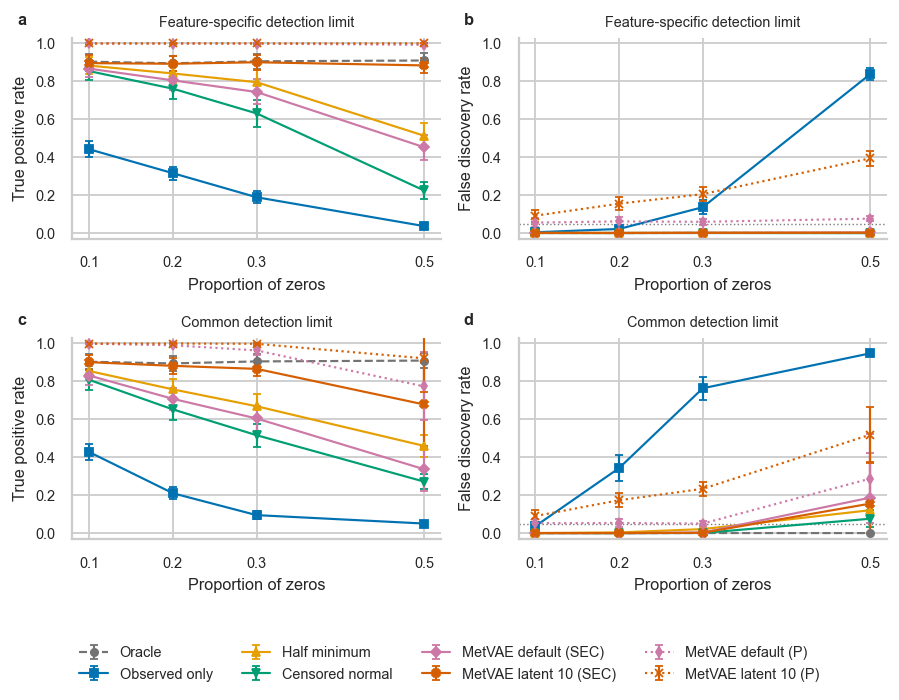

In [16]:
step_start = time.perf_counter()

with plt.rc_context(RC):
    edge_recovery_figure(edge_summary, FIGURE_SERIES_MAIN, os.path.join(FIG_DIR, 'FigureS3.pdf'))

print_step_time('Build Figure S3', step_start)
print('Figures written to', FIG_DIR)


## 6. Key numbers

Export the mean and standard deviation of true positive rate and false discovery rate for each series displayed in Figure S3.


In [18]:
records = []
for method, sparsifier, _, _ in FIGURE_SERIES_MAIN:
    for _, row in edge_summary[edge_summary['method'] == method].iterrows():
        for metric in ('tpr', 'fdr'):
            quantity = f'{metric}_{sparsifier}'
            records.append({'censor': row['censor'], 'zero_prop': row['zero_prop'],
                            'method': method, 'quantity': quantity,
                            'value': row[f'{quantity}_mean'], 'sd': row[f'{quantity}_sd'],
                            'n_reps': row['n_reps']})
key_numbers = pd.DataFrame.from_records(records).sort_values(['censor', 'zero_prop', 'quantity', 'method'])
key_numbers.to_csv(KEY_NUMBERS_PATH, index=False)
display(key_numbers.round(3))
print('Key numbers written to', KEY_NUMBERS_PATH)


Key numbers written to ../results/intermediate_results/sim_imputation_comparison_key_numbers.csv


,censor,zero_prop,method,quantity,value,sd,n_reps
97,feature,0.1,metvae_linear,fdr_bh,0.056,0.024,50
113,feature,0.1,metvae_linear_L10,fdr_bh,0.092,0.032,50
49,feature,0.1,censored_normal,fdr_sec,0.001,0.001,50
33,feature,0.1,half_minimum,fdr_sec,0.001,0.001,50
65,feature,0.1,metvae_linear,fdr_sec,0.001,0.001,50
...,...,...,...,...,...,...,...
46,floor,0.5,half_minimum,tpr_sec,0.460,0.058,50
78,floor,0.5,metvae_linear,tpr_sec,0.338,0.113,50
94,floor,0.5,metvae_linear_L10,tpr_sec,0.679,0.219,50
30,floor,0.5,observed_only,tpr_sec,0.051,0.010,50


## Runtime summary

The table below summarizes the timed steps in the order they were recorded.

In [20]:
runtime_summary = pd.Series(step_times, name='seconds').rename_axis('step').reset_index()
with pd.option_context('display.max_rows', 40):
    display(runtime_summary)
print(f"Total tracked time: {runtime_summary['seconds'].sum():.2f} seconds")

Total tracked time: 2.40 seconds


,step,seconds
0,Run or load the simulation,0.021581
1,Build Figure S3,2.376535
